# Forced simple causal models

Here, we showcase how to force simple models. 

In [1]:
import torch
import xarray as xr
import matplotlib.pyplot as plt

from causaldynamics.utils import set_rng_seed
from causaldynamics.initialization import initialize_weights, initialize_biases, initialize_x, drive_sin, drive_linear
from causaldynamics.scm import create_scm_graph, get_root_nodes_mask
from causaldynamics.mlp import propagate_mlp
from causaldynamics.systems import solve_system, solve_random_systems
from causaldynamics.plot import plot_trajectories, animate_3d_trajectories, plot_scm, plot_3d_trajectories

In [2]:
# Set a fixed seed for reproducibility
set_rng_seed(42)

Let's compare the effect of a sine forcing to a linear forcing on the same Lorenz system.

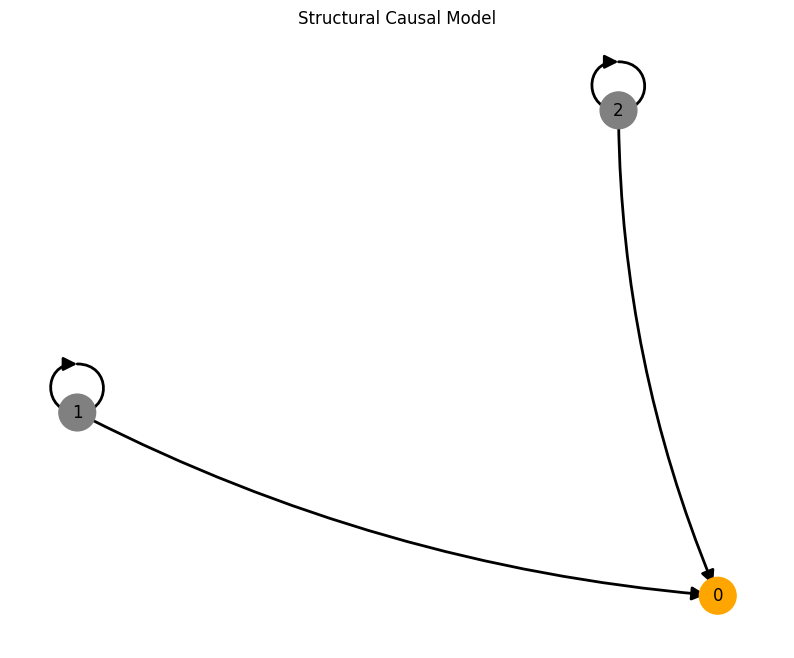

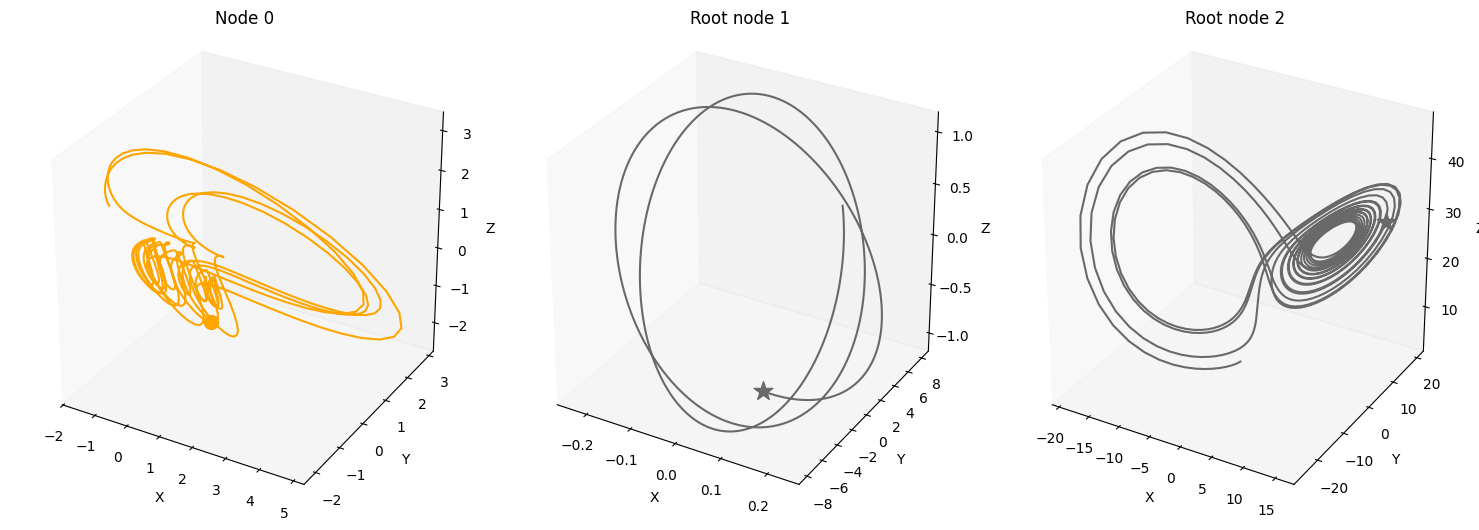

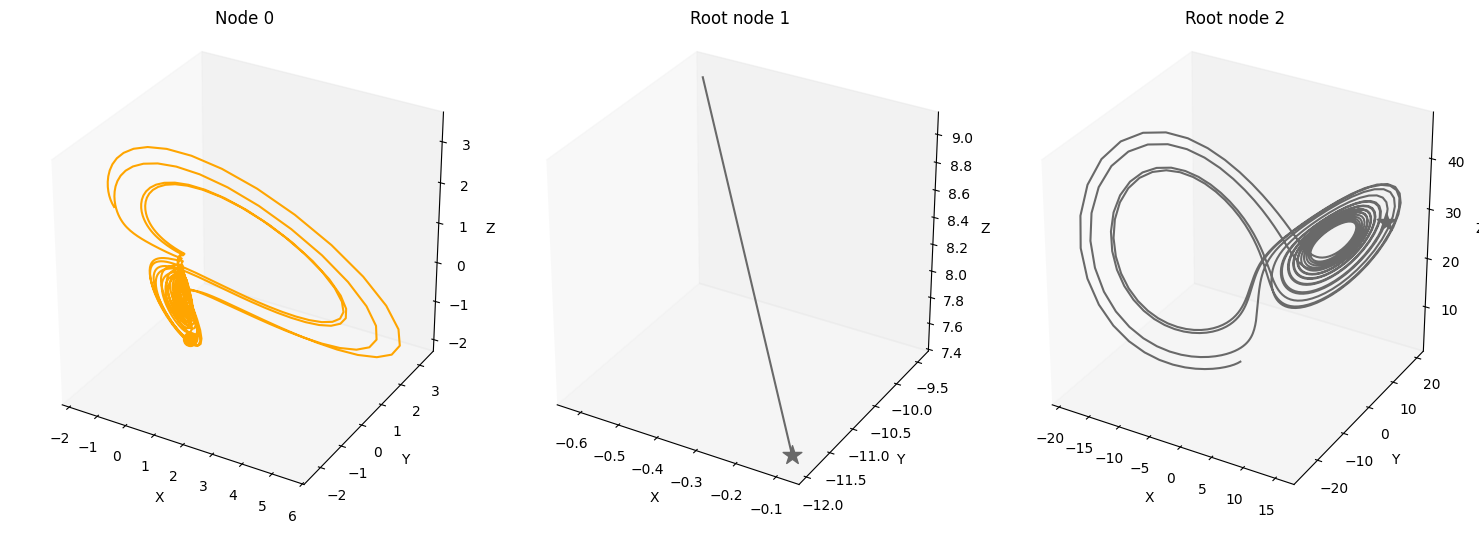

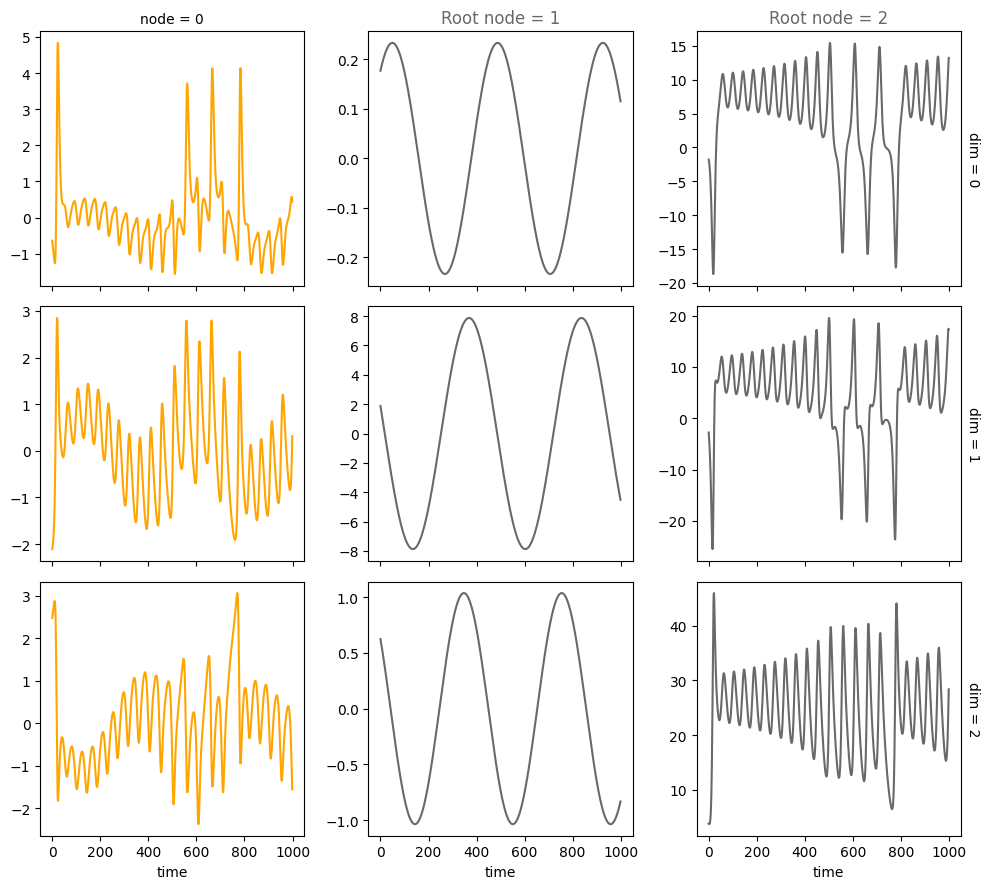

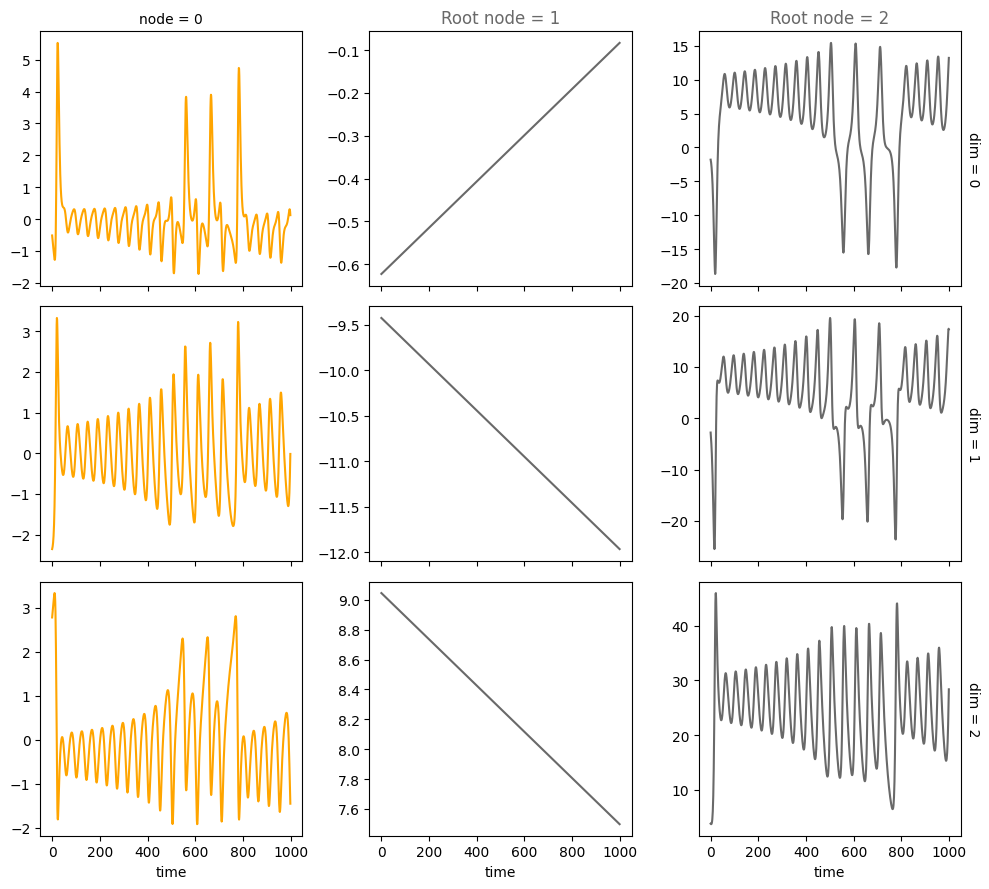

In [3]:
# Set parameters
num_nodes = 3
num_timesteps = 1000
dimensions = 3

A = torch.tensor([[0., 0., 0.],
                  [1., 0., 0.],
                  [1., 0., 0.]])
W = initialize_weights(num_nodes, dimensions)
b = initialize_biases(num_nodes, dimensions)
init = solve_system(num_timesteps, num_nodes, "Lorenz")
# init = solve_random_systems(num_timesteps, num_nodes)
init_linear = drive_linear(num_timesteps, num_nodes, dimensions, m_range=(-10., 10.), b_range=(-10., 10.))
init_sin = drive_sin(num_timesteps, num_nodes, dimensions, amplitude_range=(-10., 10.))

init[:, 1] = init_sin[:, 1]
x_sin = propagate_mlp(A, W, b, init=init, standardize=True)
init[:, 1] = init_linear[:, 1]
x_linear = propagate_mlp(A, W, b, init=init, standardize=True)
root_nodes = get_root_nodes_mask(A)
data_sin = xr.DataArray(x_sin, dims=['time', 'node', "dim"])
data_linear = xr.DataArray(x_linear, dims=['time', 'node', "dim"])

plot_scm(G=create_scm_graph(A), root_nodes=root_nodes)
plot_3d_trajectories(data_sin, root_nodes, line_alpha=1.)
plot_3d_trajectories(data_linear, root_nodes, line_alpha=1.)

plot_trajectories(data_sin, root_nodes=root_nodes, sharey=False)
plot_trajectories(data_linear, root_nodes=root_nodes, sharey=False)
plt.show()
